<a href="https://colab.research.google.com/github/saverin0/Advanced_Geospatial_Analysis/blob/main/01_raster_vector_zonal_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 · Raster basics, vector data and zonal statistics

Reads an SRTM digital surface model of Germany, inspects its metadata, plots it, loads the NUTS-1
administrative regions, and computes the mean elevation per region with `rasterstats`.
Ends with a quick look at strided down-sampling of a raster.

**Data** is downloaded on the fly into `data/` (about 90 MB for the DEM), nothing needs to be uploaded.

In [ ]:
%pip install -q rasterstats

In [ ]:
import io, os, math, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.plot import plotting_extent

DATA = Path("data")
DATA.mkdir(exist_ok=True)
FIG = Path("figures")
FIG.mkdir(exist_ok=True)


def read_preview(path, max_px=2000):
    """Read band 1 decimated so the longer side is <= max_px. Use this for plotting:
    imshow on the full 142-megapixel array needs several GB and kills small kernels."""
    with rasterio.open(path) as src:
        f = max(1, math.ceil(max(src.width, src.height) / max_px))
        arr = src.read(1, out_shape=(src.height // f, src.width // f),
                       resampling=Resampling.average, masked=True)
        return arr, plotting_extent(src)


def download(url, dest, unzip=False):
    """Download `url` to `dest` (file, or folder when unzip=True). Skips if already present."""
    dest = Path(dest)
    if dest.is_file() or (dest.is_dir() and any(dest.iterdir())):
        print("already present:", dest)
        return dest
    print("downloading:", url)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=600) as r:
        payload = r.read()
    if unzip:
        dest.mkdir(parents=True, exist_ok=True)
        zipfile.ZipFile(io.BytesIO(payload)).extractall(dest)
    else:
        dest.write_bytes(payload)
    print(f"saved: {dest}  ({len(payload) / 1e6:.1f} MB)")
    return dest

from rasterstats import zonal_stats

## Raster data: SRTM DSM of Germany

In [ ]:
# SRTM 30 m Digital Surface Model of Germany, published by OpenDEM (~90 MB zip).
SRTM_URL = "https://www.opendem.info/downloads/srtm_germany_dsm.zip"
download(SRTM_URL, DATA / "srtm_dsm", unzip=True)

raster_file = next((DATA / "srtm_dsm").rglob("*.tif"))
raster_file

already present: data\srtm_dsm


WindowsPath('data/srtm_dsm/srtm_germany_dsm.tif')

In [ ]:
with rasterio.open(raster_file) as src:
    dsm = src.read(1, masked=True)
    print("shape    :", dsm.shape)
    print("crs      :", src.crs)
    print("bounds   :", src.bounds)
    print("transform:", src.transform)
    print("count    :", src.count, "| width:", src.width, "| height:", src.height)
    print("profile  :", src.profile)

shape    : (10801, 13201)
crs      : EPSG:4326
bounds   : BoundingBox(left=4.999583333333334, bottom=46.999583333333334, right=16.000416666666666, top=56.000416666666666)
transform: | 0.00, 0.00, 5.00|
| 0.00,-0.00, 56.00|
| 0.00, 0.00, 1.00|
count    : 1 | width: 13201 | height: 10801
profile  : {'driver': 'GTiff', 'dtype': 'int16', 'nodata': None, 'width': 13201, 'height': 10801, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0008333333333333333, 0.0, 4.999583333333334,
       0.0, -0.0008333333333333333, 56.000416666666666), 'blockxsize': 13201, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}


In [ ]:
dsm

masked_array(
  data=[[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [200, 200, 200, ..., 281, 282, 286],
        [199, 199, 199, ..., 283, 281, 286],
        [201, 200, 198, ..., 282, 281, 284]],
  mask=False,
  fill_value=np.int64(999999),
  dtype=int16)

In [ ]:
# Reuse the array read above instead of loading the 285 MB raster a second time.
with rasterio.open(raster_file) as src:
    print(f"CRS       : {src.crs}")
    print(f"Resolution: {src.res[0]} x {src.res[1]} {src.crs.linear_units if src.crs.is_projected else 'degrees'}")
print(f"Shape     : {dsm.shape} (rows, cols)")
print(f"Pixels    : {dsm.shape[0] * dsm.shape[1] / 1e6:.1f} megapixels")
print(f"Elevation : min = {dsm.min():.1f} m | mean = {dsm.mean():.1f} m | max = {dsm.max():.1f} m")

CRS       : EPSG:4326
Resolution: 0.0008333333333333333 x 0.0008333333333333333 degrees
Shape     : (10801, 13201) (rows, cols)
Pixels    : 142.6 megapixels


Elevation : min = 0.0 m | mean = 264.6 m | max = 3730.0 m


### Plotting

`imshow` on the full 142-megapixel array converts it to float RGBA internally and peaks at
roughly 4.5 GB of RAM, enough to kill the kernel on a small runtime. `read_preview` asks
rasterio to decimate while reading, so the plot costs a few megabytes and looks identical.

preview shape: (1543, 1885)


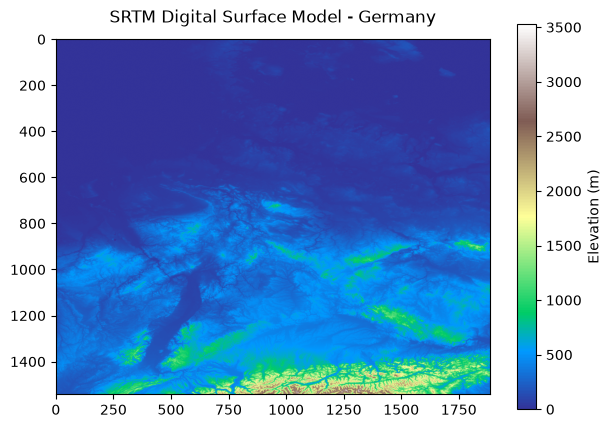

In [ ]:
preview, extent = read_preview(raster_file)
print("preview shape:", preview.shape)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(preview, cmap="terrain", vmin=preview.min(), vmax=preview.max())
plt.colorbar(im, ax=ax, label="Elevation (m)")
ax.set_title("SRTM Digital Surface Model - Germany", pad=12)
plt.show()

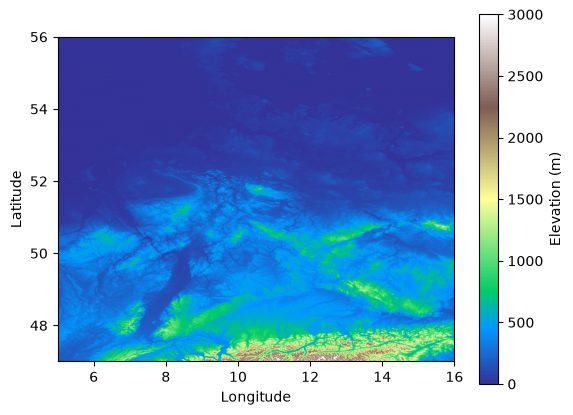

In [ ]:
plt.imshow(preview, extent=extent, cmap="terrain", vmin=0, vmax=3000)
plt.colorbar(label="Elevation (m)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.show()

## Vector data: NUTS-1 regions

In [ ]:
# NUTS level-1 regions (2016, 1:1M, EPSG:4326) straight from Eurostat GISCO.
NUTS_URL = ("https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
            "NUTS_RG_01M_2016_4326_LEVL_1.geojson")
nuts_file = download(NUTS_URL, DATA / "NUTS_RG_01M_2016_4326_LEVL_1.geojson")

gdf_nuts1 = gpd.read_file(nuts_file)
gdf_nuts1.head()

already present: data\NUTS_RG_01M_2016_4326_LEVL_1.geojson


,LEVL_CODE,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,NAME_ASCI,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,1,BE3,BE,RÉGION WALLONNE,RÉGION WALLONNE,R&#x00C9;GION WALLONNE,0,0,0,Belgium,Belgique,BEL,UN Member State,Brussels,T,F,F,Belgien,"MULTIPOLYGON (((5.69837 50.80445, 5.69155 50.7..."
1,1,CH0,CH,SCHWEIZ/SUISSE/SVIZZERA,SCHWEIZ/SUISSE/SVIZZERA,SCHWEIZ/SUISSE/SVIZZERA,0,0,0,Switzerland,Suisse,CHE,UN Member State,Bern,F,T,F,Schweiz,"MULTIPOLYGON (((8.57249 47.80563, 8.57657 47.8..."
2,1,DE1,DE,BADEN-WÜRTTEMBERG,BADEN-WÜRTTEMBERG,BADEN-W&#x00DC;RTTEMBERG,0,0,0,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland,"MULTIPOLYGON (((9.65093 49.78083, 9.64486 49.7..."
3,1,CY0,CY,Kypros,ΚΥΠΡΟΣ,Kypros,0,0,0,Cyprus,Chypre,CYP,UN Member State,Nicosia,T,F,F,Zypern,"MULTIPOLYGON (((34.58451 35.69436, 34.57359 35..."
4,1,DEA,DE,NORDRHEIN-WESTFALEN,NORDRHEIN-WESTFALEN,NORDRHEIN-WESTFALEN,0,0,0,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland,"MULTIPOLYGON (((8.65204 52.53093, 8.67125 52.5..."


In [ ]:
sorted(set(gdf_nuts1.CNTR_CODE))

['AL',
 'AT',
 'BE',
 'BG',
 'CH',
 'CY',
 'CZ',
 'DE',
 'DK',
 'EE',
 'EL',
 'ES',
 'FI',
 'FR',
 'HR',
 'HU',
 'IE',
 'IS',
 'IT',
 'LI',
 'LT',
 'LU',
 'LV',
 'ME',
 'MK',
 'MT',
 'NL',
 'NO',
 'PL',
 'PT',
 'RO',
 'RS',
 'SE',
 'SI',
 'SK',
 'TR',
 'UK']

In [ ]:
gdf_nuts1 = gdf_nuts1[gdf_nuts1.CNTR_CODE == "DE"].copy()
len(gdf_nuts1)

16

In [ ]:
print("NUTS-1 layer summary")
print(f"  CRS            : {gdf_nuts1.crs}")
print(f"  Record count   : {len(gdf_nuts1)}")
print(f"  Extent         : {gdf_nuts1.total_bounds.round(3)}  (xmin, ymin, xmax, ymax)")
print(f"  Attribute cols : {list(gdf_nuts1.columns)}")

NUTS-1 layer summary
  CRS            : EPSG:4326
  Record count   : 16
  Extent         : [ 5.868 47.27  15.041 55.058]  (xmin, ymin, xmax, ymax)
  Attribute cols : ['LEVL_CODE', 'NUTS_ID', 'CNTR_CODE', 'NAME_LATN', 'NUTS_NAME', 'NAME_ASCI', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'NAME_ENGL', 'NAME_FREN', 'ISO3_CODE', 'SVRG_UN', 'CAPT', 'EU_STAT', 'EFTA_STAT', 'CC_STAT', 'NAME_GERM', 'geometry']


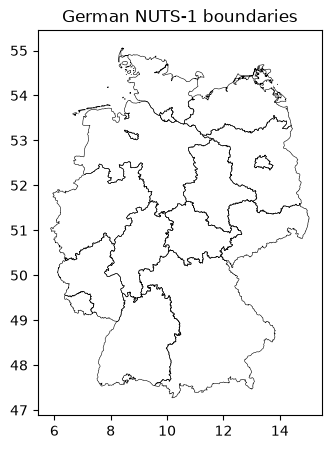

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
gdf_nuts1.boundary.plot(ax=ax, linewidth=0.4, edgecolor="black")
ax.set_title("German NUTS-1 boundaries")
plt.show()

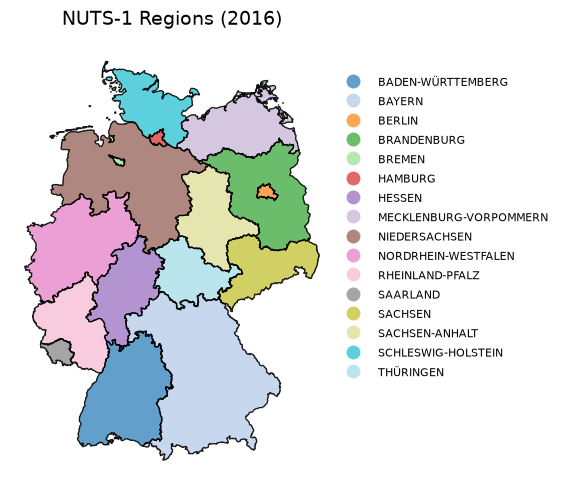

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
gdf_nuts1.boundary.plot(ax=ax, linewidth=0.4, edgecolor="black")

legend = gdf_nuts1.plot(
    ax=ax, column="NUTS_NAME", categorical=True, legend=True,
    alpha=0.7, cmap="tab20", edgecolor="black",
).get_legend()
legend.set_bbox_to_anchor((1.7, 0.95), transform=ax.transAxes)
legend.set_frame_on(False)
for txt in legend.get_texts():
    txt.set_fontsize(8)

ax.set_title("NUTS-1 Regions (2016)", fontsize=14, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Zonal statistics: mean elevation per region

In [ ]:
with rasterio.open(raster_file) as src:
    raster_crs = src.crs

print("vector CRS:", gdf_nuts1.crs)
print("raster CRS:", raster_crs)

vector CRS: EPSG:4326
raster CRS: EPSG:4326


In [ ]:
import warnings

# rasterstats warns that the file has no nodata value; that is expected here, so silence
# only that call rather than every warning in the notebook.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    stats = zonal_stats(
        vectors=gdf_nuts1.to_crs(raster_crs),
        raster=str(raster_file),
        stats=["mean", "median", "min", "max"],
    )
stats[:3]

[{'min': 26.0, 'max': 1491.0, 'mean': 493.03796519308383, 'median': 483.0},
 {'min': 0.0, 'max': 849.0, 'mean': 174.68479286465106, 'median': 102.0},
 {'min': 64.0, 'max': 949.0, 'mean': 303.3428758124907, 'median': 302.0}]

In [ ]:
gdf_nuts1["mean_elev_m"] = [s["mean"] for s in stats]
gdf_nuts1[["NUTS_ID", "NUTS_NAME", "mean_elev_m"]].sort_values("mean_elev_m", ascending=False)

,NUTS_ID,NUTS_NAME,mean_elev_m
21,DE2,BAYERN,513.501020
2,DE1,BADEN-WÜRTTEMBERG,493.037965
19,DEG,THÜRINGEN,363.149000
11,DEB,RHEINLAND-PFALZ,323.608657
14,DEC,SAARLAND,310.182905
6,DE7,HESSEN,303.342876
16,DED,SACHSEN,292.633683
4,DEA,NORDRHEIN-WESTFALEN,174.684793
15,DEE,SACHSEN-ANHALT,117.590640
28,DE9,NIEDERSACHSEN,69.717473


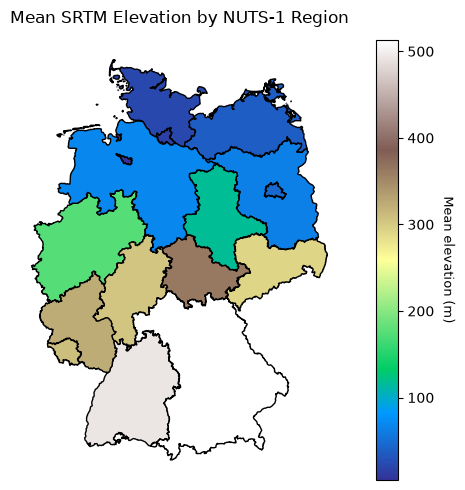

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
gdf_nuts1.plot(ax=ax, column="mean_elev_m", cmap="terrain", legend=True, edgecolor="black")

cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Mean elevation (m)", rotation=270, labelpad=15, fontsize=9)

ax.set_title("Mean SRTM Elevation by NUTS-1 Region", pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG / "01_mean_elevation_nuts1.png", dpi=150, bbox_inches="tight")
plt.show()

## Down-sampling a raster with a stride

Keeping every *n*-th row and column keeps roughly `1/n²` of the pixels. Given a target
percentage of pixels to keep, the stride is `round(sqrt(100 / percent))`.

Note: this GeoTIFF has no nodata value set, so every pixel (including sea, stored as 0 m)
counts as valid. With a raster that flags nodata, the mask below would exclude those pixels.

In [ ]:
sample_percent = 0.9   # keep ~0.9 % of the valid pixels
stride = max(1, int(round(math.sqrt(1 / (sample_percent / 100)))))
stride

11

In [ ]:
raster = dsm                                   # the band read at the top of the notebook
with rasterio.open(raster_file) as src:
    transform = src.transform

valid_mask = ~np.ma.getmaskarray(raster)
valid_pix = int(valid_mask.sum())
print("Down-sampling summary")
print(f"  Stride                    : {stride}")
print(f"  Total valid pixels        : {valid_pix:,}")

# Build only the strided (row, col) pairs, then drop the invalid ones.
# (np.where over every valid pixel would allocate two 1.1 GB index arrays.)
h, w = raster.shape
rows_s, cols_s = np.meshgrid(np.arange(0, h, stride), np.arange(0, w, stride), indexing="ij")
rows_s, cols_s = rows_s.ravel(), cols_s.ravel()
print(f"  Strided candidates         : {len(rows_s):,}")

keep = valid_mask[rows_s, cols_s]
rows, cols = rows_s[keep], cols_s[keep]
print(f"  Kept after subsample       : {len(rows):,}  ({len(rows) / valid_pix:.2%} of valid pixels)")

Down-sampling summary
  Stride                    : 11
  Total valid pixels        : 142,584,001
  Strided candidates         : 1,179,382
  Kept after subsample       : 1,179,382  (0.83% of valid pixels)
